# DECISION TREE:

##A **Decision Tree** is a **tree-like model** used to make predictions by asking a series of questions or conditions.

### It works like a **flowchart**.

## KEY POINTS

* **Supervised Learning Algorithm**
* Used for **Classification and Regression**
* Makes decisions using **conditions**
* Has a **tree-like structure**

## STRUCTURE

### ROOT NODE

* The **starting point** of the tree.
* Contains the **first/best split**.

### BRANCHES

* Show the **different outcomes** of a split.

### LEAF NODE

* The **final point** of the tree.
* Gives the **final prediction**.

## SIMPLE STRUCTURE

**ROOT NODE**

↓

**BRANCHES**

↓

**SUB-NODES**

↓

**LEAF NODE → FINAL PREDICTION**

### REMEMBER

**Root → Starting point**

**Branch → Decision/Outcome**

**Leaf → Final Prediction**

---

# CHOOSING THE BEST SPLIT

### :To decide **which feature should be used to split the data**, a Decision Tree uses **Entropy** and **Information Gain (IG)**.

## 1. ENTROPY → MEASUREMENT OF IMPURITY

**Entropy measures how mixed or impure the classes are in a dataset or subset.**

* **Entropy = 0** → Completely pure (only one class)
* **Higher Entropy** → Classes are more mixed
* **Maximum Entropy = 1** → Classes are completely mixed in a binary classification problem

## Entropy Formula:

### Entropy(S) = −Σ Pi log₂(Pi)

Where:

* **S** → Dataset or subset
* **Pi** → Proportion of observations belonging to class *i*
* **i** → Each class in the dataset

---

# 2. INFORMATION GAIN (IG):

###Information Gain measures how much impurity is reduced after splitting the data.

## Formula:

### Information Gain = Entropy(Parent) − Weighted Entropy(Children)

For example, if we are checking different features:

### AGE

**IG(AGE) = Entropy(Parent) − Weighted Entropy(Children after AGE split)**

### EAT

**IG(EAT) = Entropy(Parent) − Weighted Entropy(Children after EAT split)**

### EX

**IG(EX) = Entropy(Parent) − Weighted Entropy(Children after EX split)**

We calculate the Information Gain for each possible feature.

### HIGHEST INFORMATION GAIN → BEST SPLIT

The feature with the **highest Information Gain** is selected as the **Root Node (first split)**.

---

# 3. DIVIDE AND CONQUER METHOD

A Decision Tree follows the **Divide and Conquer** approach:

**Parent Dataset**

↓

**Choose the Best Split**

↓

**Divide the Dataset into Subsets**

↓

**Find the Best Split for Each Subset**

↓

**Continue Splitting**

↓

**Final Leaf Nodes / Predictions**


The process continues until a stopping condition is reached.

---

# IMPORTANT TERMS

### C → Number of Classes:

The number of different class levels in the target variable.

### Pi → Proportion of Values in a Class:

The proportion of observations belonging to class **i**.

**Pi = Number of observations in class i / Total observations**

### S → Dataset or Subset:

The dataset or a particular subset of the dataset for which entropy is being calculated.

### E(S):

**E(S) = Entropy of dataset/subset S**

### E(S1):

**E(S1) = Entropy of subset S1**

If a parent dataset is divided into **S1** and **S2**, their entropies are calculated separately and then combined using their respective sizes to obtain the **Weighted Entropy**.


In [27]:
# n=2
# Entropy(S1)= -p log  p - p log  p
#                1   2  1   2   2  2
#            = - p(yes)*log  p(yes) - p(no)*log  p(no)
#                          2                   2
#            = -(16/30)*log  (16/30) -(14/30)*log (14/30)
#                          2                     2
#            = 0.99

# E(balace)= WEIGHTED AVG[E(B<50K) & E(B>=50K)]
# E(B<50K)= -(12/13)*log (12/13) - (1/13)*log (1/13)
#                       2                    2
#         = 0.39

# E(B>=50K)= -(4/17)*log (4/17) - (13/17)*log (13/17)
#                       2                    2
#          = 0.79

# E(balance)= (13/30)*0.39 + (17/30)*0.79
#           =0.69

# IG(balance)=E(S1) - E(balance)
#            =0.99 - 0.69
#            =0.37


# E(Residence)= WEIGHTED AVG[E(own),E(rent) & E(other)]
# E(own)= -(7/8)*log (7/8) - (1/8)*log (1/8)
#                   2                 2
#       = 0.54

# E(rent)= -(4/10)*log (4/10) - (6/10)*log (6/10)
#                      2                    2
#       = 0.97

# E(other)=  -(5/12)*log (5/12) - (7/12)*log (7/12)
#                      2                    2
#       = 0.98

# E(Residence)= (8/30)*0.54 + (10/30)*0.97 + (12/30)*0.98
#             = 0.86

# IG(Residence)= E(S1) - E(Residence)
#              = 0.99 - 0.86
#              = 0.13

# ROOT NODE=IG(B)>IG(RES)==> BALANCE


In [28]:
import pandas as pd
df=pd.read_csv("/content/Copy of diabetes.csv")
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [30]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [31]:
df.duplicated().sum()

np.int64(0)

In [32]:
df.Outcome.value_counts()

,count
Outcome,
0,500
1,268


In [33]:
x=df.iloc[:,:8]
x

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33
...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63
764,2,122,70,27,0,36.8,0.340,27
765,5,121,72,23,112,26.2,0.245,30
766,1,126,60,0,0,30.1,0.349,47


In [34]:
y=df.Outcome
y

,Outcome
0,1
1,0
2,1
3,0
4,1
...,...
763,0
764,0
765,0
766,1


In [35]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest=train_test_split(x,y,test_size=0.3,random_state=41)

In [36]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
scaler.fit(xtrain)
xtrain=scaler.transform(xtrain)
xtrain

array([[ 0.69026007,  1.40938446,  0.21844489, ..., -0.6922818 ,
        -0.5036029 ,  2.96450972],
       [ 0.07144595,  0.11423785, -0.00403952, ..., -0.39860595,
         1.95122858,  1.08595408],
       [-0.85677523,  2.26228589, -1.11646157, ..., -0.78166141,
         0.52216597, -0.79260155],
       ...,
       [ 0.69026007, -0.0752958 , -1.11646157, ..., -0.62843923,
         2.45972939,  0.01249372],
       [-0.23796111, -0.29641839,  0.21844489, ..., -0.05385603,
        -0.81630167, -0.70314652],
       [-0.23796111, -0.26482945, -1.45018819, ..., -1.22855946,
        -0.98287952, -0.97151161]])

In [37]:
xtest=scaler.transform(xtest)
xtest

array([[-0.54736817, -0.64389675, -0.67149275, ..., -0.99872618,
         0.40234681, -0.88205658],
       [ 1.3090742 ,  0.14582679,  0.99714032, ...,  0.82717154,
        -0.37209407,  1.4437742 ],
       [-0.85677523,  0.55648303, -0.44900834, ...,  1.10807888,
         0.17439818, -1.06096664],
       ...,
       [ 2.8561095 , -0.54912993,  0.10720268, ..., -0.10493009,
        -0.03309353,  0.45976887],
       [-0.85677523, -0.67548569, -0.22652393, ..., -1.07533727,
         0.55431257, -0.61369149],
       [ 1.61848126, -0.29641839,  0.66341371, ..., -0.48798556,
         2.35452233,  1.53322923]])

In [38]:
from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state=41)
xtrain1, ytrain1 = sm.fit_resample(xtrain, ytrain)

In [39]:
ytrain1.value_counts()

,count
Outcome,
0,347
1,347


In [40]:
# decision tree
from sklearn.tree import DecisionTreeClassifier
dt=DecisionTreeClassifier()

In [41]:
# model training
dt.fit(xtrain1,ytrain1)

DecisionTreeClassifier()

In [42]:
ypred=dt.predict(xtest)
ypred

array([0, 0, 1, 0, 0, 1, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0,
       1, 1, 0, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0,
       1, 0, 1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1,
       0, 0, 1, 1, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 1,
       0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1, 0, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1,
       0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 1,
       1, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1])

In [43]:
ytest

,Outcome
679,0
345,0
486,0
20,0
457,0
...,...
494,0
652,0
635,1
224,0


In [44]:
from sklearn.metrics import accuracy_score
acc=accuracy_score(ytest,ypred)
acc

0.7316017316017316

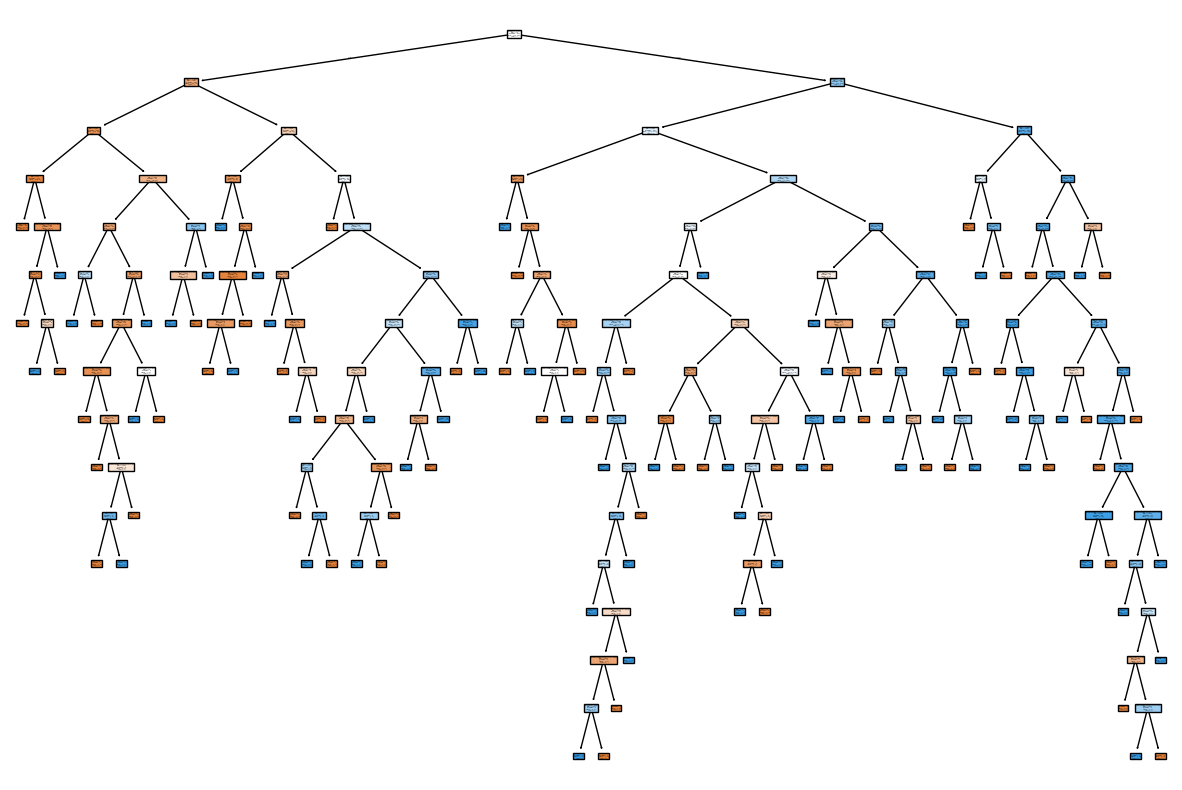

In [45]:
import matplotlib.pyplot as plt
from sklearn import tree

plt.figure(figsize=(15,10))

tree.plot_tree(dt,feature_names=x.columns,
    class_names=df.Outcome.astype(str).unique(),
    filled=True)

plt.show()

In [46]:
training_score=dt.score(xtrain,ytrain)
training_score

1.0

In [47]:
testing_score=dt.score(xtest,ytest)
testing_score
# THIS IS AN OVERFITTED MODEL

0.7316017316017316

## OVERFITTED MODEL: An overfitted model is a model that performs very well on the training data but poorly on the testing data.

## UNDERFITTED MODEL: An underfitted model is a model that performs poorly on both the training data and testing data because it has not learned the patterns in the data sufficiently.

## GOOD MODEL: A good model is a model that performs well on both training data and testing data, with a relatively small difference between the two.